In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

plt.rcParams.update({
    "figure.dpi":120,
    "axes.spines.top":False,
    "axes.spines.right":False,
    "axes.titlesize":13,
    "axes.labelsize":11,
})
ACCENT = "#e8925a"
print("Load")

Load


In [2]:
df = pd.read_csv("games.csv")
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
df.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

The header row has 39 names, but every data row has 40 values, seems like because the csv merged Discount and DLC count into one header name DiscountDLC count

In [4]:
# Splitting DLC count and Discount
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

print("Done")

# got the error of length mismatch. so instead of adding one more col, I just drop the AppID cause it doesnt seem like it is needed for the prediction

Done


In [5]:
print(f"Shape: {df.shape}")

Shape: (125855, 39)


In [6]:
print(f"Column types:\n{df.dtypes}")

Column types:
Name                           object
Release date                   object
Estimated owners               object
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                 object
Supported languages            object
Full audio languages           object
Reviews                        object
Header image                   object
Website                        object
Support url                    object
Support email                  object
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                 object
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int6

In [7]:
missing_summary = pd.DataFrame({"n_missing": df.isna().sum(),"percent_missing": (df.isna().mean() * 100).round(1),}).sort_values("percent_missing", ascending=False)
print(f"Missingness per column:\n{missing_summary.to_string()}")


Missingness per column:
                            n_missing  percent_missing
Movies                         125855            100.0
Score rank                     125815            100.0
Metacritic url                 121597             96.6
Reviews                        113674             90.3
Notes                          102545             81.5
Website                         75335             59.9
Support url                     70560             56.1
Tags                            42502             33.8
Support email                   22630             18.0
Categories                       8966              7.1
Publishers                       8922              7.1
Genres                           8423              6.7
Developers                       8449              6.7
About the game                   8462              6.7
Screenshots                      6027              4.8
Header image                       81              0.1
Negative                            0    

Some col are almost empty. but before deciding which col to keep and which to remove, I'll move to the Estimated owners first as later on based on this I can define the a threshold. The reason if based the client question is about commercial success but the dataset has no col that directly says a game was susscessful. Luckily client also mentioned the pathway that I must "define and justify an ownership-based success threshold based on the observed ownership distribution"

In [8]:
owners_counts = df['Estimated owners'].value_counts()
print(owners_counts)

Estimated owners
0 - 20000                75705
0 - 0                    24579
20000 - 50000            11397
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2856
500000 - 1000000          1155
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64


In [9]:
order = sorted(owners_counts.index, key=lambda s: (int(s.split(' - ')[0]), int(s.split(' - ')[1])))
owners_ordered = owners_counts.loc[order]
print(owners_ordered)

Estimated owners
0 - 0                    24579
0 - 20000                75705
20000 - 50000            11397
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2856
500000 - 1000000          1155
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64


In [10]:
owners_table = pd.DataFrame({
    'n_games': owners_ordered,
    'percent': (owners_ordered / len(df) * 100).round(1),
})
owners_table['cumulative_percent'] = owners_table['percent'].cumsum().round(1)
print(owners_table.to_string())

                       n_games  percent  cumulative_percent
Estimated owners                                           
0 - 0                    24579     19.5                19.5
0 - 20000                75705     60.2                79.7
20000 - 50000            11397      9.1                88.8
50000 - 100000            5355      4.3                93.1
100000 - 200000           3454      2.7                95.8
200000 - 500000           2856      2.3                98.1
500000 - 1000000          1155      0.9                99.0
1000000 - 2000000          729      0.6                99.6
2000000 - 5000000          405      0.3                99.9
5000000 - 10000000         125      0.1               100.0
10000000 - 20000000         51      0.0               100.0
20000000 - 50000000         31      0.0               100.0
50000000 - 100000000         9      0.0               100.0
100000000 - 200000000        4      0.0               100.0


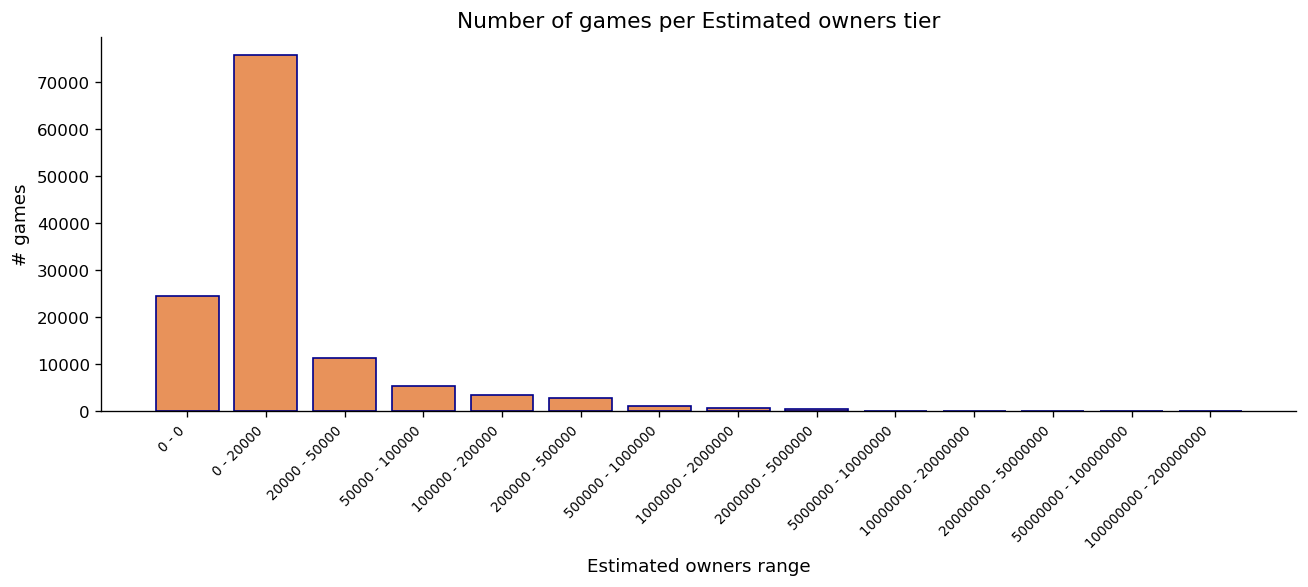

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(owners_ordered)), owners_ordered.values, color=ACCENT, edgecolor='darkblue')
ax.set_xticks(range(len(owners_ordered)))
ax.set_xticklabels(owners_ordered.index, rotation=45, ha='right', fontsize=8)
ax.set_title("Number of games per Estimated owners tier")
ax.set_xlabel("Estimated owners range")
ax.set_ylabel("# games")
plt.tight_layout()
plt.show()

Estimated owners col sorts every game into one of 14 groups. The 0-0 holds 24579 (19.5%) and 0-20000 holds 75705 (60.2%) = 79.7% of all games. Based on this we can see how the games spread across the tiers. After that each tier is smaller than the one below it. For example, 20000-50000 (9.1%), 50000-100000 (4.3%), 100000-200000 (2.7%), 200000-500000 (2.3%) and every tier above 500000 owners is under 1% on its own.
Since both client questions are yes or no, I turn this into a binary label. First, I set the success line at 50000+ so a game counts as a success if it lands in the 50000-100000 tier or any higher tier. The reason is it sits on a real tier boundary and it put the bar at a game that actually sold well which fits the client's idea of a high ownership tier. Under this line 14,174 games (11.26%) are labelled success and the rest are not.

Worth to notice the 0-0 is interesting here like why it even here? 

Next step. Client says to exclude non game listings (like demos, utilities, soundtracks) using metadata and to consider whether extremely large AAA titles should be treated separately but client also says i must not filter the core sample on post-launch outcomes like review count or owners. But I still have the question related to the 0-0 so I'll start from there first. 

In [12]:
# look closer in the 0-0 to see what they are
zero = df[df['Estimated owners'] == '0 - 0'].copy()
print(f"'0-0' rows: {len(zero):,} ({len(zero)/len(df)*100:.1f}% of all games)")

'0-0' rows: 24,579 (19.5% of all games)


In [13]:
zero_dates = pd.to_datetime(zero['Release date'], errors='coerce')
ref_point = pd.Timestamp('2026-08-08')
print(f"Release dates that fail to parse : {zero_dates.isna().sum():,}")
print(f"Future (after {ref_point.date()}) : {(zero_dates > ref_point).sum():,}")
print(f"Past (on or before today) : {(zero_dates <= ref_point).sum():,}")

Release dates that fail to parse : 0
Future (after 2026-08-08) : 2
Past (on or before today) : 24,577


In [14]:
print(f"Price for '0-0':")
print(zero['Price'].describe().round(2).to_string())

Price for '0-0':
count    24579.00
mean         2.77
std         14.85
min          0.00
25%          0.00
50%          0.00
75%          1.69
max        199.99


Out of 24579 rows in that tier every release date parses only 2 are dated in the future and 24577 are dated on or before today so these are released games. Price is cheap. 
So these are released games that got almost no traction. The 0-0 bucket is defined by estimated owners and the zero reviews are also a post-launch result so both are outcomes I am not allowed to filter on.

Next step is look into the non game listings. First is to break the genre into single tokens and count them.

In [15]:
genre_tokens = df['Genres'].dropna().str.split(',').explode().str.strip()
print("Genre tokens and counts:")
print(genre_tokens.value_counts().to_string())

Genre tokens and counts:
Genres
Indie                    82884
Casual                   51677
Action                   47344
Adventure                46293
Simulation               24912
Strategy                 23058
RPG                      21577
Free To Play             12605
Early Access             11572
Sports                    4971
Racing                    4169
Massively Multiplayer     2596
Utilities                 1091
Design & Illustration      584
Animation & Modeling       484
Education                  464
Violent                    414
Video Production           340
Game Development           323
Gore                       257
Audio Production           229
Software Training          222
Photo Editing              183
Web Publishing             113
Nudity                      94
Sexual Content              88
Accounting                  32
Movie                        2
Documentary                  1
Episodic                     1
Short                        1
Tutoria

The large ones are real game genres like Indie, Casual, Action, Adventure, Simulation, Strategy, RPG, Free To Play, Early Access, Sports, Racing, Massively Multiplayer. Those stay.
Then there is a block of software / non game application genres: Utilities, Design & Illustration, Animation & Modeling, Video Production, Game Development, Audio Production, Software Training, Photo Editing, Web Publishing, Accounting. Plus a few tiny video content ones like Movie, Documentary, Short, 360 Video, Tutorial, Episodic. These are the utilities type listings client wants us to consider excluding. Note that Education can be an educational game or educational software so keep for now.

What confused me is Violent, Gore, Nudity, Sexual Content. Those def doesnt look like genre so I asked ChatGPT 
BEGIN ChatGPT I got these in the dataset inthe gerne but it doesn look like one what these could be?
END
It could be the labels attached to the games not a seperate products so I'll keep them.

In [16]:
name = df['Name'].fillna("")
for pat in ['Soundtrack','OST','Demo','Artbook','Art Book']:
    print(f"'{pat}': {name.str.contains(pat, case=False).sum():,}")

'Soundtrack': 3
'OST': 1,592
'Demo': 492
'Artbook': 1
'Art Book': 1


OST and Demo number are significant higher than others. What I could think of is that the pattern matched any substring case-insensitively so OST also matches words like Ghost, Lost, Frost, Boston and same as Demo. So those counts prolly inflated by ordinary words

In [17]:
# BEGIN ChatGPT I got the prolly inlated number of OST and Demo cause the pattern matched any substring case-insensitively.
# How can I check first then avoid this
# END
name = df['Name'].fillna("")
patterns = {
    'soundtrack': r'\bsoundtrack\b',
    'OST': r'\bost\b',
    'demo': r'\bdemo\b',
    'art book': r'\bart\s?book\b',
}
for label, pat in patterns.items():
    n = name.str.contains(pat, case=False, regex=True).sum()
    print(f"Name matches {label}: {n:,}")

Name matches soundtrack: 3
Name matches OST: 1
Name matches demo: 84
Name matches art book: 2


So the earlier OST and Demo were almost entirely false matches from words like Ghost and Demon.

In [18]:
# candidate non game
owners_lower = df['Estimated owners'].str.split(' - ').str[0].astype(int)
df['success'] = (owners_lower >= 50000).astype(int)
nongame_genres = [
    'Utilities', 'Design & Illustration', 'Animation & Modeling', 'Video Production',
    'Game Development', 'Audio Production', 'Software Training', 'Photo Editing',
    'Web Publishing', 'Accounting', 'Movie', 'Documentary', 'Short', '360 Video',
    'Tutorial', 'Episodic'
]
game_genres = [
    'Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG',
    'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer'
]

In [19]:
g = df['Genres'].fillna("")
tokens = g.apply(lambda s: [x.strip() for x in s.split(',')])
has_nongame = tokens.apply(lambda t: any(x in nongame_genres for x in t))
has_game    = tokens.apply(lambda t: any(x in game_genres for x in t))
print(f"Rows with at least one non game genre: {has_nongame.sum():,}")
print(f"also have a core game genre: {(has_nongame & has_game).sum():,}")
print(f"no core game genre (pure non game): {(has_nongame & ~has_game).sum():,}")

Rows with at least one non game genre: 1,726
also have a core game genre: 634
no core game genre (pure non game): 1,092


In [20]:
name = df['Name'].fillna("")
name_nongame = name.str.contains(r'\bsoundtrack\b|\bost\b|\bdemo\b|\bart\s?book\b',case=False, regex=True)
print(f"Rows flagged by name (soundtrack/OST/demo/art book): {name_nongame.sum():,}")

Rows flagged by name (soundtrack/OST/demo/art book): 90


In [21]:
# row has non game genre even if it alsi has a game genre
flagged_all = has_nongame | name_nongame
# has non game genre and no game genre
flagged_pure = (has_nongame & ~has_game) | name_nongame
print(f"Any non game: {flagged_all.sum():,}")
print(f"Pure non game: {flagged_pure.sum():,}")

Any non game: 1,811
Pure non game: 1,178


1726 rows have at least one non game genre but 634 of those also carry a real game genre so they are probably actual games and I keep them. That leaves 1092 pure non game rows. 
Adding the name-flagged listings and removing overlap gives 1178 rows removed in total. Also I left Education in the sample since it can be an educational game or educational software and I did not want to cut real games on an ambiguous label.
So the only sample filter here is removing these 1,178 non game listings. I did not filter on owners or reviews, since those are outcomes.

In [22]:
# build the cleaned sample
drop_mask = (has_nongame & ~has_game) | name_nongame
steps = [("raw", len(df))]
df_games = df[~drop_mask].copy()
steps.append(("remove non game listings", len(df_games)))
print("rows surviving each step:")
for label, n in steps:
    print(f" {label:<26s} {n:>8,d}  ({n/len(df)*100:5.1f}% of raw)")

rows surviving each step:
 raw                         125,855  (100.0% of raw)
 remove non game listings    124,677  ( 99.1% of raw)


In [23]:
print(f"removed: {drop_mask.sum():,} rows")
print(df_games['success'].value_counts())
print(f"success rate: {df_games['success'].mean():.4f}")

removed: 1,178 rows
success
0    110607
1     14070
Name: count, dtype: int64
success rate: 0.1129


okey done. Next is the genre features. have to turn the comma separeated genres into one binary col per core game genre

In [24]:
# 1: game lists that genre 0: not
genre_dummies = df_games['Genres'].str.get_dummies(sep=',')
core_genres = ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer']
print("games tagged with each core genre:")
print(genre_dummies[core_genres].sum().sort_values(ascending=False).to_string())

games tagged with each core genre:
Indie                    82838
Casual                   51663
Action                   47320
Adventure                46263
Simulation               24902
Strategy                 23052
RPG                      21564
Free To Play             12574
Early Access             11567
Sports                    4969
Racing                    4165
Massively Multiplayer     2594


In [25]:
none_core = (genre_dummies[core_genres].sum(axis=1) == 0).sum()
print(f"\ngames with none of the core genres: {none_core:,} ({none_core/len(df_games)*100:.1f}%)")


games with none of the core genres: 8,518 (6.8%)


Seems like genres are multi-label they add up to far more than 124,677 because a game can have several. 
That 8518 group is the thing to decide. It is prolly mostly games with no genre listed at all but let me check.

In [26]:
no_core = genre_dummies[core_genres].sum(axis=1) == 0
print(f"missing genres entirely: {df_games.loc[no_core, 'Genres'].isna().sum():,}")
print(f"have a genre but no core game genre: {df_games.loc[no_core, 'Genres'].notna().sum():,}")

missing genres entirely: 8,401
have a genre but no core game genre: 117


alright so of the 8518 exactly 8401 have no genre listed at all and 117 have only a non-core genre. So it is overwhelmingly a missing genre group. We keep them with all zero genre flags.

In [27]:
# next feature: platforms, price, required age
df_games['plat_windows']= df_games['Windows'].astype(int)
df_games['plat_mac']= df_games['Mac'].astype(int)
df_games['plat_linux']= df_games['Linux'].astype(int)
print("games available on each platform:")
print(df_games[['plat_windows', 'plat_mac', 'plat_linux']].sum().to_string())

games available on each platform:
plat_windows    124643
plat_mac         21540
plat_linux       15975


In [28]:
print(f"Price: median {df_games['Price'].median():.2f}, max {df_games['Price'].max():.2f}")
print("\nRequired age counts:")
print(df_games['Required age'].value_counts().sort_index().to_string())

Price: median 2.39, max 999.98

Required age counts:
Required age
0     123390
1          2
3          6
6          4
7          5
10        27
12        23
13       176
14         1
15         3
16        32
17       837
18       168
20         1
21         2


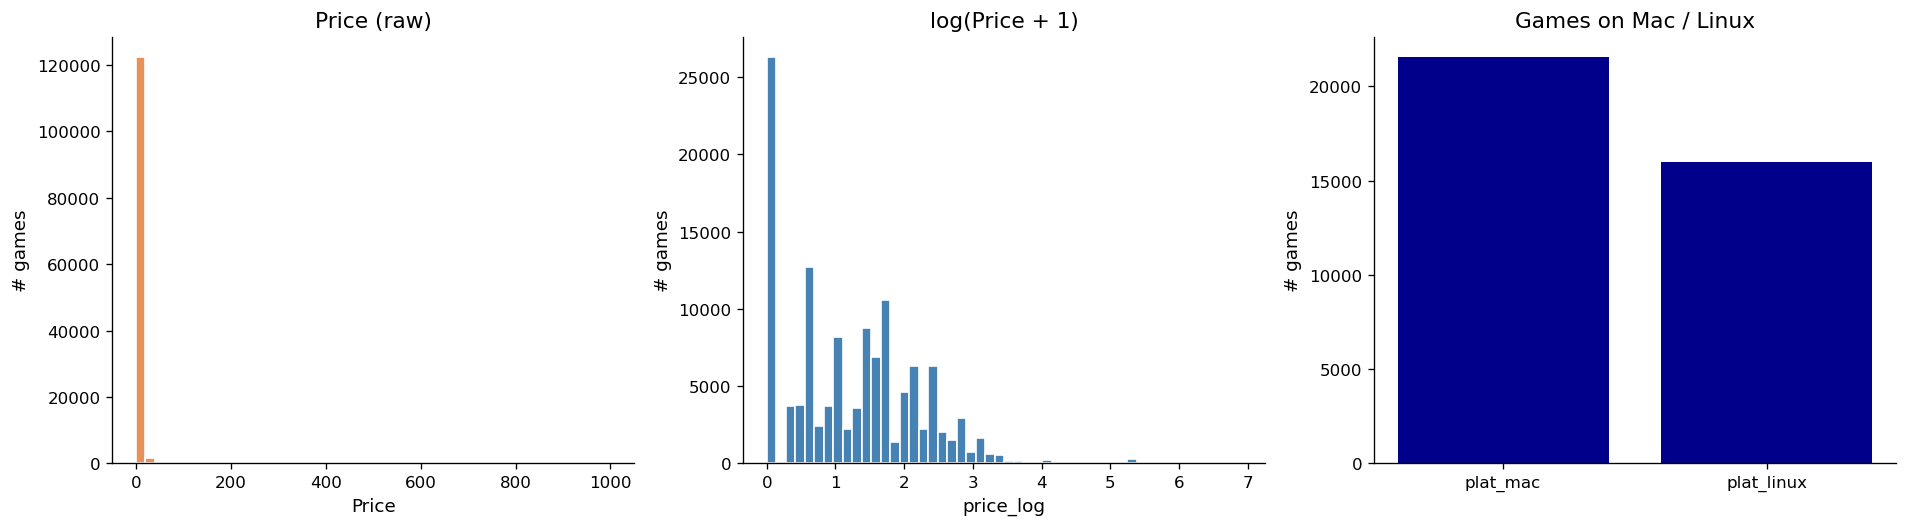

In [29]:
df_games['age_restricted'] = (df_games['Required age'] > 0).astype(int)
df_games['price_log'] = np.log1p(df_games['Price'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df_games['Price'], bins=50, color=ACCENT, edgecolor='white')
axes[0].set_title("Price (raw)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("# games")

axes[1].hist(df_games['price_log'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title("log(Price + 1)")
axes[1].set_xlabel("price_log")
axes[1].set_ylabel("# games")

plat = df_games[['plat_mac', 'plat_linux']].sum()
axes[2].bar(plat.index, plat.values, color='darkblue')
axes[2].set_title("Games on Mac / Linux")
axes[2].set_ylabel("# games")

plt.tight_layout()
plt.show()

Platforms: Windows is on 124643/124677 games so almost every game. That column is basically constant (only 34 games differ) so it carries no real signal and I would drop plat_windows and keep plat_mac and plat_linux which actually vary.

Required age: it is 0 for 123390 games. As a raw feature it is close to useless. I would turn it into a simple binary flag instead age_restricted = 1 if Required age is above 0 else 0. That captures the only real distinction (has an age gate or not) without pretending the exact number matters.

Price: median 2.39 but max 999.98 so it is heavily right-skewed. After a log(price+1) transform the distribution spreads into a readable range with a tall spike at 0 for the free games and the rest spread roughly between 0.5 and 3.5. So I use price_log as the price feature

In [30]:
# next is language and release timing
langs = df_games['Supported languages'].fillna('')
df_games['n_languages'] = langs.str.count(',') + 1
df_games.loc[langs.str.strip().isin(['', '[]']), 'n_languages'] = 0
print(df_games['n_languages'].describe().round(2).to_string())

count    124677.00
mean          5.26
std          13.63
min           0.00
25%           1.00
50%           1.00
75%           4.00
max         103.00


In [31]:
rel = pd.to_datetime(df_games['Release date'], errors='coerce')
df_games['release_year']  = rel.dt.year
df_games['release_month'] = rel.dt.month
print(f"release_year range: {int(df_games['release_year'].min())} - {int(df_games['release_year'].max())}")

release_year range: 1997 - 2026


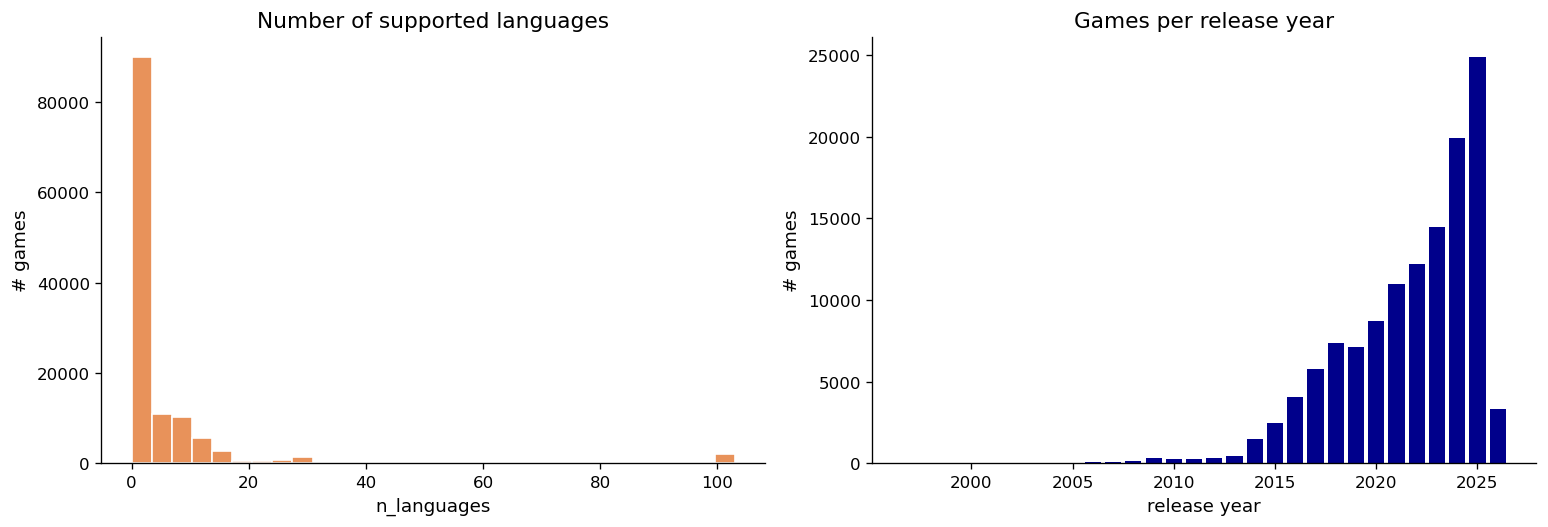

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df_games['n_languages'], bins=30, color=ACCENT, edgecolor='white')
axes[0].set_title("Number of supported languages")
axes[0].set_xlabel("n_languages")
axes[0].set_ylabel("# games")

year_counts = df_games['release_year'].value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values, color='darkblue')
axes[1].set_title("Games per release year")
axes[1].set_xlabel("release year")
axes[1].set_ylabel("# games")

plt.tight_layout()
plt.show()

Languages: right-skewed.
Release year: the range is 1997 to 2026 and the right plot shows games are heavily concentrated in recent years, very few before about 2010 -> The catalog is mostly recent games and older games are rare which is exactly why release year mixes in exposure time

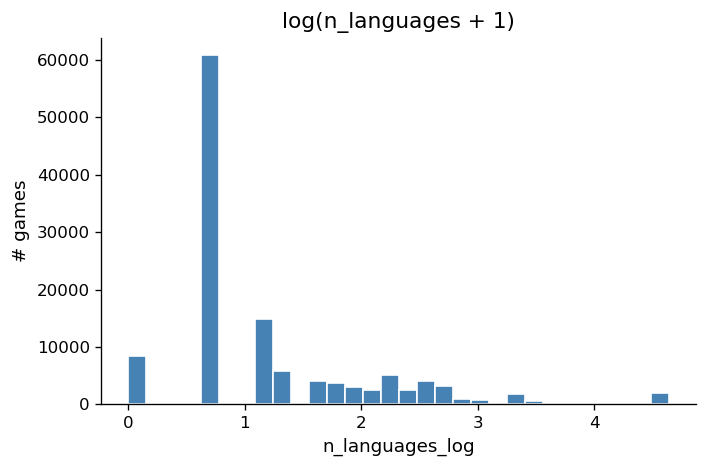

In [33]:
# log
df_games['n_languages_log'] = np.log1p(df_games['n_languages'])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_games['n_languages_log'], bins=30, color='steelblue', edgecolor='white')
ax.set_title("log(n_languages + 1)")
ax.set_xlabel("n_languages_log")
ax.set_ylabel("# games")
plt.tight_layout()
plt.show()

In [34]:
print(df_games['n_languages'].value_counts().sort_index().head(10))

n_languages
0     8371
1    60801
2    14850
3     5774
4     4122
5     3756
6     3054
7     2566
8     2561
9     2587
Name: count, dtype: int64


ya makes sense too have the 1 at 60801 which means games that support a single language, most likely English only

In [35]:
# next is developer and publisher
# check cardinality
print("unique developers:", df_games['Developers'].nunique())
print("unique publishers:", df_games['Publishers'].nunique())
print("missing developers:", df_games['Developers'].isna().sum())
print("missing publishers:", df_games['Publishers'].isna().sum())


unique developers: 72235
unique publishers: 64002
missing developers: 8428
missing publishers: 8898


In [36]:
same = (df_games['Developers'].fillna('') == df_games['Publishers'].fillna('')) & df_games['Developers'].notna()
print(f"self-published (developer == publisher): {same.sum():,} ({same.mean()*100:.1f}%)")

self-published (developer == publisher): 82,197 (65.9%)


There are 72235 unique developers and 64002 unique publishers so these fields are far too high cardinality to use as identities and for Pixel Publishing's own decision the publisher would always be themselves.
Any "how many games has this studio made" feature would also count games released after the one being scored, which is future information leaking in. So I do not use the raw developer or publisher names. What I do use is whether a game is self-published meaning the developer and publisher are the same text which is a single clean signal known at launch. I add this as is_self_published and drop the raw name fields.

In [37]:
df_games['is_self_published'] = ((df_games['Developers'].fillna('') == df_games['Publishers'].fillna(''))& df_games['Developers'].notna()).astype(int)
print(df_games['is_self_published'].value_counts().to_string())

is_self_published
1    82197
0    42480


In [38]:
# assemble the pre-launch feature matrix
core_genres = ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer']
genre_dummies = df_games['Genres'].str.get_dummies(sep=',')
X = pd.concat([genre_dummies[core_genres],df_games[['plat_mac', 'plat_linux', 'age_restricted', 'price_log', 'n_languages_log', 'release_year', 'release_month', 'is_self_published']]], axis=1)
print("feature matrix shape:", X.shape)
print("any missing values in X:", X.isnull().sum().sum())
print("\nfeatures:", X.columns.tolist())

feature matrix shape: (124677, 20)
any missing values in X: 0

features: ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer', 'plat_mac', 'plat_linux', 'age_restricted', 'price_log', 'n_languages_log', 'release_year', 'release_month', 'is_self_published']


In [39]:
y = df_games['success']
print("Target balance:")
print(y.value_counts().to_string())

Target balance:
success
0    110607
1     14070


Putting the groups together, the pre-launch feature matrix X has 124677 rows and 20 columns with no missing values. The features are the 12 genre flags, two platform flags (plat_mac, plat_linux), age_restricted, price_log, n_languages_log, release_year, release_month, is_self_published. The target y is okey with 14070 successes and 110607 non-successe.

I left out the post-launch fields (Peak CCU, Positive, Negative, Recommendations, playtime, user score, Metacritic) and the Estimated owners column itself since those are outcomes or would leak the target. I also left out Discount and DLC count which the brief flags as possibly changing after launch and the raw developer and publisher names which are too high cardinality to use as identities.

In [40]:
overall = y.mean()
rows = []
for g in core_genres:
    mask = X[g] == 1
    rows.append({'genre': g, 'n_games': int(mask.sum()), 'success_rate': y[mask].mean()})
genre_success = pd.DataFrame(rows).sort_values('success_rate', ascending=False)
print(f"Overall success rate: {overall:.3f}")
print(genre_success.round(3).to_string(index=False))

Overall success rate: 0.113
                genre  n_games  success_rate
Massively Multiplayer     2594         0.235
                  RPG    21564         0.164
             Strategy    23052         0.152
               Action    47320         0.138
         Free To Play    12574         0.133
            Adventure    46263         0.129
           Simulation    24902         0.125
               Racing     4165         0.117
                Indie    82838         0.108
               Sports     4969         0.104
         Early Access    11567         0.081
               Casual    51663         0.077


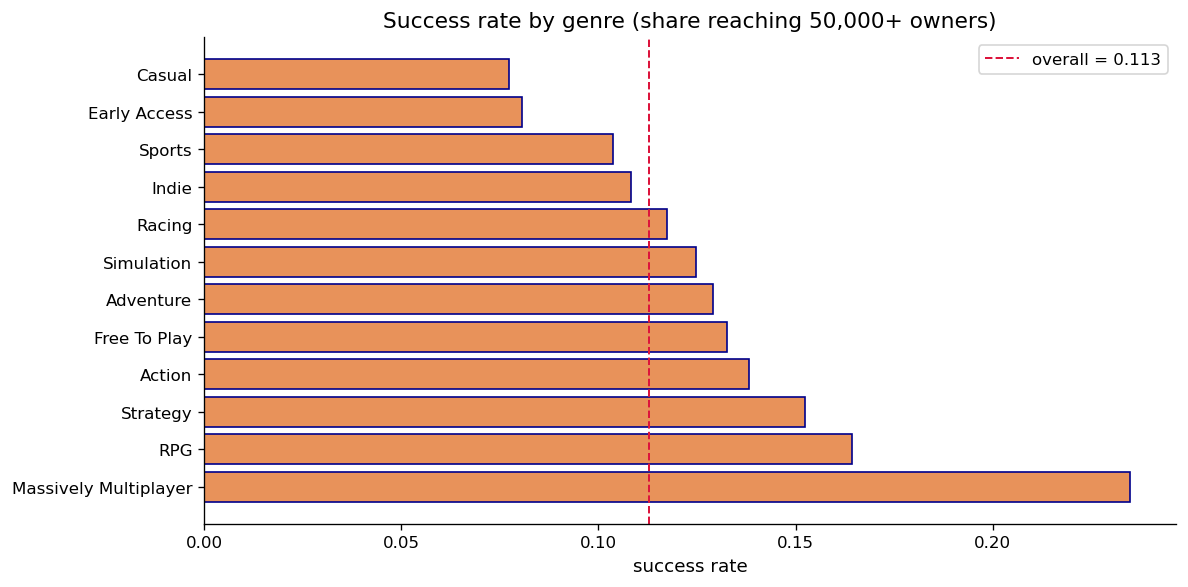

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(genre_success['genre'], genre_success['success_rate'], color=ACCENT, edgecolor='darkblue')
ax.axvline(overall, color='crimson', ls='--', lw=1.2, label=f'overall = {overall:.3f}')
ax.set_xlabel('success rate')
ax.set_title('Success rate by genre (share reaching 50,000+ owners)')
ax.legend()
plt.tight_layout()
plt.show()

The overall success rate is 0.113. The observed success rate ranges from 0.077 for casual up to 0.235 for Massively Multiplayer. Below the overall rate sit Indie (0.108), Sports (0.104), Early Access (0.081), Casual (0.077). The rest are above.
Genres are multi-label so a game can count in several of these at once and this simple breakdown does not account for price, platforms, release timing or anything else. So it only shows how success rates differ across genres in the raw data. Whether genre still matters once we account for the other features is what I test that later.

Next EDA is price

In [42]:
bands = pd.cut(df_games['Price'], bins=[-0.01, 0, 5, 15, 30, 1000],
               labels=['Free', '0-5', '5-15', '15-30', '30+'])
price_success = df_games.groupby(bands, observed=True)['success'].agg(['size', 'mean'])
price_success.columns = ['n_games', 'success_rate']
print(price_success.round(3).to_string())

       n_games  success_rate
Price                       
Free     26290         0.088
0-5      66508         0.111
5-15     26546         0.131
15-30     4299         0.190
30+       1034         0.116


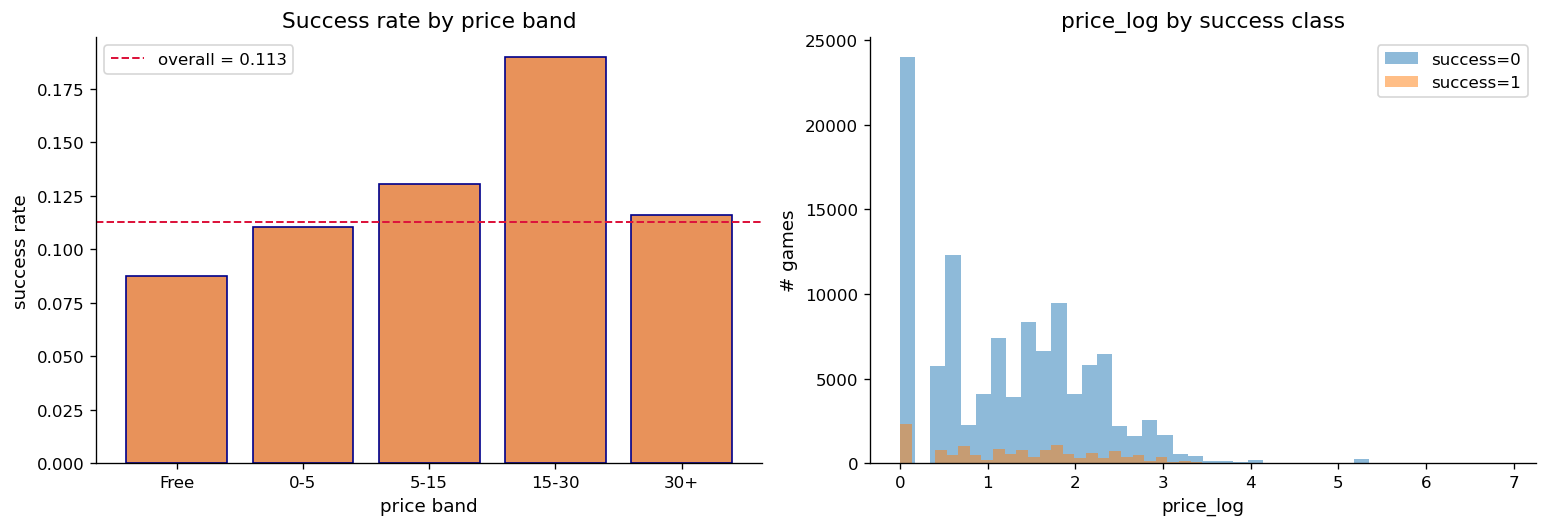

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(price_success.index.astype(str), price_success['success_rate'],
            color=ACCENT, edgecolor='darkblue')
axes[0].axhline(y.mean(), color='crimson', ls='--', lw=1.2, label=f'overall = {y.mean():.3f}')
axes[0].set_title('Success rate by price band')
axes[0].set_xlabel('price band')
axes[0].set_ylabel('success rate')
axes[0].legend()

for lbl, sub in df_games.groupby('success'):
    axes[1].hist(sub['price_log'], bins=40, alpha=0.5, label=f'success={lbl}')
axes[1].set_title('price_log by success class')
axes[1].set_xlabel('price_log')
axes[1].set_ylabel('# games')
axes[1].legend()

plt.tight_layout()
plt.show()

So I grouped games into price bands and looked at the success rate in each. Free games are the lowest at 0.088. Then it goes up as price goes up, 0-5 is 0.111 and 5-15 is 0.131 and it peaks at 0.190 in the 15-30 band. But after that it drops back down to 0.116 for the 30+ games. So its not just higher price means more success. It climb to a peak in the middle then comes back down. Also the top two bands are pretty small (4299 games in 15-30 and only 1034 above 30) so I wont read too much into them. And this is just the raw numbers, I havent accounted for genre or anything yet, so it's only a rough pattern for now.

In [44]:
# Next EDA piece
# BEGIN CHATGPT I tried to split games into has it vs does not have it and shows the success rate of each group but why it is not working?
flags = ['plat_mac', 'plat_linux', 'is_self_published', 'age_restricted']
rate_when_1 = [y[X[c] == 1].mean() for c in flags]
rate_when_0 = [y[X[c] == 0].mean() for c in flags]
for c, r1, r0 in zip(flags, rate_when_1, rate_when_0):
    print(f"{c:<18s}=1: {r1:.3f}=0: {r0:.3f}")
# END

plat_mac          =1: 0.192=0: 0.096
plat_linux        =1: 0.177=0: 0.103
is_self_published =1: 0.090=0: 0.158
age_restricted    =1: 0.605=0: 0.108


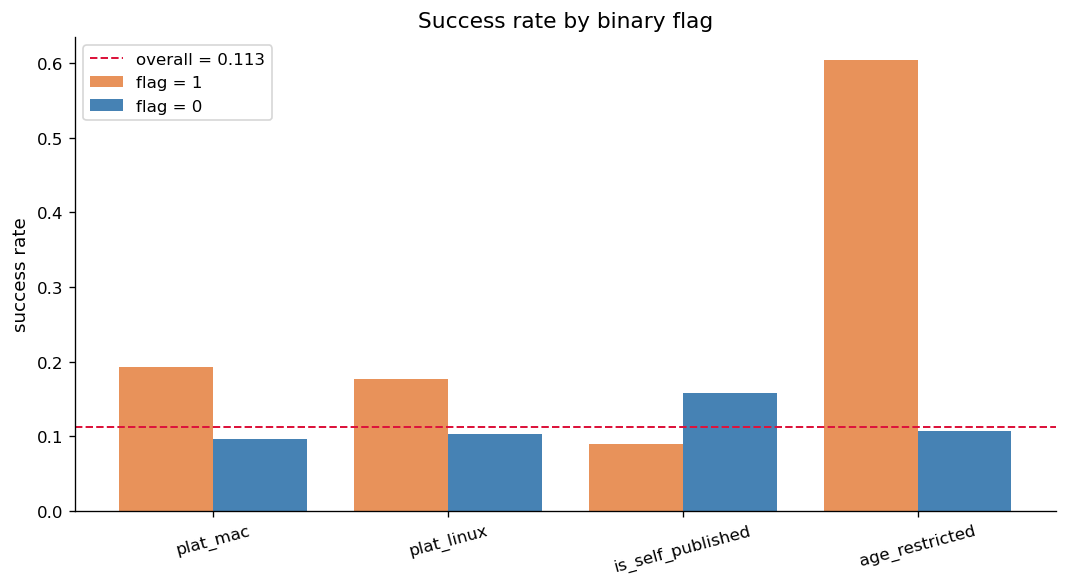

In [45]:
xpos = np.arange(len(flags))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xpos - 0.2, rate_when_1, width=0.4, color=ACCENT, label='flag = 1')
ax.bar(xpos + 0.2, rate_when_0, width=0.4, color='steelblue', label='flag = 0')
ax.axhline(y.mean(), color='crimson', ls='--', lw=1.2, label=f'overall = {y.mean():.3f}')
ax.set_xticks(xpos)
ax.set_xticklabels(flags, rotation=15)
ax.set_ylabel('success rate')
ax.set_title('Success rate by binary flag')
ax.legend()
plt.tight_layout()
plt.show()

So here I looked at the success rate for each of the four yes (1) / no (0) flags
plat_mac: games on Mac succeed at 0.192 vs only 0.096 when not on Mac, so about double. plat_linux is the same story, 0.177 on Linux vs 0.103 off it. is_self_published goes the other way, self-published games succeed less (0.090) than games that are not self-published (0.158). And age_restricted is the biggest gap by far, age-restricted games succeed at 0.605 vs 0.108 for the rest.
I wanna be careful with that last one tho there are only about 1287 age restricted games so the 0.605 is coming from a pretty small group. And all of this is still raw and not adjusted for genre, price, or anything else, and these flags probably tie in with other things (like age restricted games might be bigger budget titles) so I just read it as a raw pattern for now.

In [46]:
# rate by release year
# M5: success rate by release year
year_success = df_games.groupby('release_year')['success'].agg(['size', 'mean'])
year_success.columns = ['n_games', 'success_rate']
print(year_success.round(3).to_string())

              n_games  success_rate
release_year                       
1997                2         1.000
1998                1         1.000
1999                2         1.000
2000                2         1.000
2001                4         1.000
2002                1         1.000
2003                3         1.000
2004                6         1.000
2005                7         0.714
2006               69         0.841
2007               90         0.889
2008              158         0.671
2009              321         0.598
2010              255         0.647
2011              260         0.785
2012              317         0.814
2013              457         0.783
2014             1494         0.559
2015             2467         0.400
2016             4050         0.333
2017             5789         0.197
2018             7350         0.141
2019             7122         0.127
2020             8714         0.147
2021            10967         0.117
2022            12191       

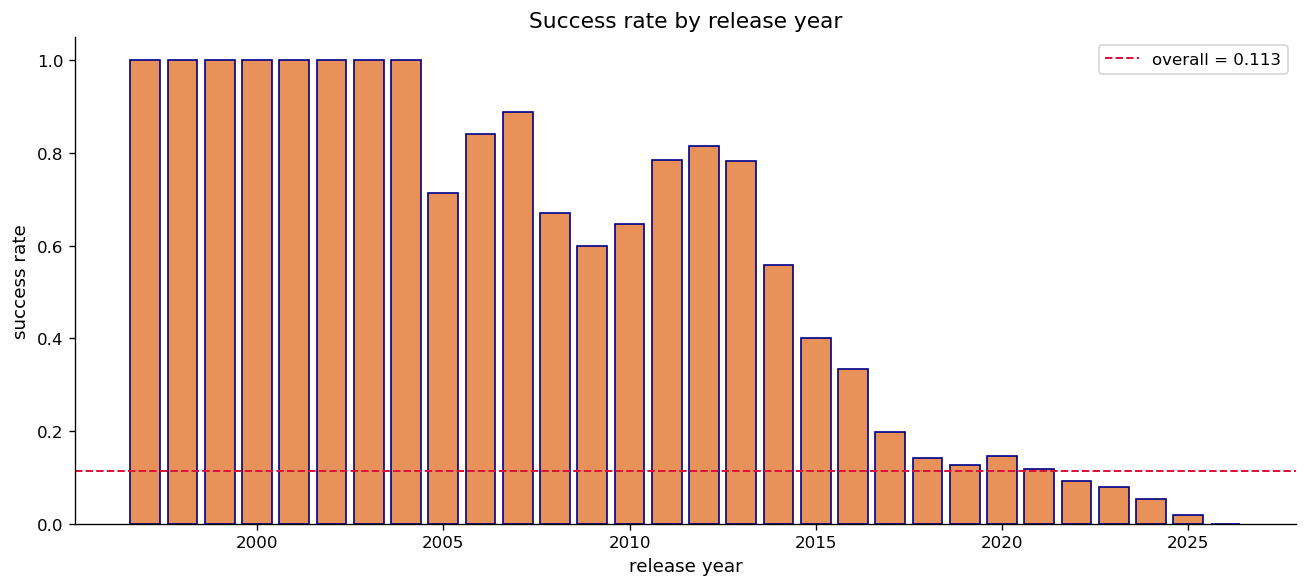

In [47]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(year_success.index, year_success['success_rate'], color=ACCENT, edgecolor='darkblue')
ax.axhline(y.mean(), color='crimson', ls='--', lw=1.2, label=f'overall = {y.mean():.3f}')
ax.set_xlabel('release year')
ax.set_ylabel('success rate')
ax.set_title('Success rate by release year')
ax.legend()
plt.tight_layout()
plt.show()

The success rate fall as release year gets more recent. The years from 1997 - 2004 all show 1.000 but each has only 1 to 6 games so I do not rely on them. After that it drops fastly. I dont read this as older games being better. It is the snapshot issue that estimated owners is counted as of now so an older game has had far more time to accumulate owners than a recent one. So release_year is mostly capturing how long a game has been out not a pre-launch quality and I drop it from the model features so the model cannot score a game just by its age.

So I think I will drop release_year from the features and keep release_month. Also keep the full sample rather than restricting the years. cause dropping release_year removes the worst of the exposure leakage so the model cannot score a game just by its age and keeping the full sample means all the EDA I already have still stands

In [48]:
X = X.drop(columns='release_year', errors='ignore')
print("feature matrix now:", X.shape)
print(X.columns.tolist())

feature matrix now: (124677, 19)
['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer', 'plat_mac', 'plat_linux', 'age_restricted', 'price_log', 'n_languages_log', 'release_month', 'is_self_published']


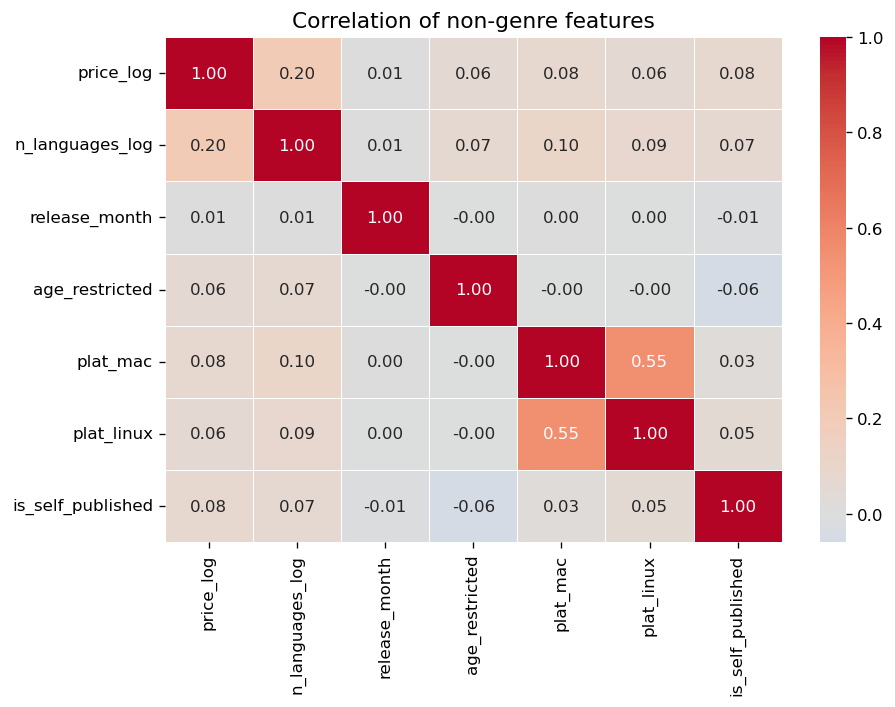

In [49]:
num_feats = ['price_log', 'n_languages_log', 'release_month', 'age_restricted', 'plat_mac', 'plat_linux', 'is_self_published']
corr = X[num_feats].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.35, ax=ax)
ax.set_title('Correlation of non-genre features')
plt.tight_layout()
plt.show()

So putting all the EDA pieces together, a few raw patterns show up. Success rates change by genre, from about 8% for Casual up to 24% for Massively Multiplayer. Price goes up to a peak in the 15-30 dollar band (0.190) then drops off. Games on Mac or Linux succeed at about double the rate of games that arent. Self published games do a bit worse than non self published ones. And age restricted games have a way higher rate (0.605), but thats only from about 1287 games so I dont lean on it.
The biggest and most important finding I got here is the release year. The success rate drops steeply the newer the game is which is the snapshot problem that estimated owners is counted as of now so older games just had more time to reach 50000. Cause of that I dropped release_year from the features.
I also checked the correlations between the non genre features and nothing is strongly correlated. The only medium one is plat_mac and plat_linux at 0.55 which makes sense since Mac games are often on Linux too but its not high enough to be a real problem so yeah Ill keep both.

In [50]:
# Move to the question 1: genre-only predictive model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} Test: {X_test.shape}")
print(f"Train success rate: {y_train.mean():.3f} Test success rate: {y_test.mean():.3f}")


Train: (99741, 19) Test: (24936, 19)
Train success rate: 0.113 Test success rate: 0.113


In [51]:
genre_cols = ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'Strategy', 'RPG', 'Free To Play', 'Early Access', 'Sports', 'Racing', 'Massively Multiplayer']
clf_genre = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_genre.fit(X_train[genre_cols], y_train)
y_prob_genre = clf_genre.predict_proba(X_test[genre_cols])[:, 1]
y_pred_genre = clf_genre.predict(X_test[genre_cols])
print(classification_report(y_test, y_pred_genre, target_names=['not success', 'success']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_genre):.4f}")

              precision    recall  f1-score   support

 not success       0.93      0.60      0.73     22122
     success       0.17      0.64      0.27      2814

    accuracy                           0.61     24936
   macro avg       0.55      0.62      0.50     24936
weighted avg       0.84      0.61      0.68     24936

ROC-AUC: 0.6537


I split the data 80/20 stratified so both sides keep the 11.3% success rate and trained a logistic regression using only the 12 genre columns. On the test set it gets a ROC-AUC of 0.654. Cause I used class_weight balanced it catches 64% of the real successes (recall 0.64), but its precision on success is only 0.17 so when it flags a game as a success it is usually wrong. An AUC of 0.654 is better than random (0.5) but not by a lot. So genre on its own does carry some signal about which games succeed but as a standalone predictor it is weak.

In [52]:
# check adjusted association
# genres + other pre-launch features together
X_logit = sm.add_constant(X.astype(float))
model_logit = sm.Logit(y, X_logit).fit(disp=False)

In [53]:
# odds ratios and p-values for the genre terms
genre_table = pd.DataFrame({
    'odds_ratio': np.exp(model_logit.params[genre_cols]),
    'p_value': model_logit.pvalues[genre_cols]
}).sort_values('odds_ratio', ascending=False)
print(genre_table.round(4).to_string())

                       odds_ratio  p_value
Massively Multiplayer      1.8434   0.0000
Free To Play               1.4817   0.0000
RPG                        1.4708   0.0000
Strategy                   1.4480   0.0000
Action                     1.3935   0.0000
Simulation                 1.1357   0.0000
Adventure                  1.0512   0.0134
Racing                     1.0070   0.9006
Indie                      0.9308   0.0007
Sports                     0.7512   0.0000
Early Access               0.6659   0.0000
Casual                     0.4992   0.0000


So here I fit all the features together and looked at the odds ratio for each genre after I account for price, platform, languages, self-published, month. I find that yeah genres are still tied to success even after adjusting. I see that almost all of them are significant (p < 0.05), the only one not is Racing (0.9006) which basically sits at no effect.
For the genres with an or above 1 I read them as having higher odds of success with the other features held constant. I see Massively Multiplayer is the strongest at 1.84 so I read that as MMO games having about 1.84x the odds of success of non-MMO games all else equal then Free To Play, RPG, Strategy, Action. For the ones below 1 I read lower odds like Casual is the lowest at 0.4992 then Early Access, Sports, Indie.
Worth to note that I treat these as associations not causes cause an or above 1 just means games with that genre are more likely to succeed in the data not that the genre makes them succeed. Also since I have 124k rows almost everything comes out significant so I look at the size of the or not just the p-value. Thats why Id call Indie a real but tiny effect while Id call Casual and MMO the big ones.
I also notice this lines up with my raw EDA (MMO high, Casual, Early Access low) so I read genre as carrying its own signal on top of the other features. 

So for me that answers Q1: certain genres stay tied to success even after I account for the other characteristics.

In [54]:
# predictive model for question2
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
clf_full = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_full.fit(X_train_s, y_train)
y_prob_full = clf_full.predict_proba(X_test_s)[:, 1]
y_pred_full = clf_full.predict(X_test_s)
print(classification_report(y_test, y_pred_full, target_names=['not success', 'success']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_full):.4f}")
print(f"\nGenre-only baseline AUC (for ref): {roc_auc_score(y_test, y_prob_genre):.4f}")

              precision    recall  f1-score   support

 not success       0.94      0.71      0.81     22122
     success       0.22      0.66      0.33      2814

    accuracy                           0.70     24936
   macro avg       0.58      0.68      0.57     24936
weighted avg       0.86      0.70      0.75     24936

ROC-AUC: 0.7437

Genre-only baseline AUC (for ref): 0.6537


So here I trained the same logistic regression but on all 19 pre-launch features instead of just genre, using the same split and the same balanced weighting so it is a fair comparison. On the test set I get a ROC-AUC of 0.744 up from 0.654 for the genre-only baseline so about +0.09. 
So I read this as the extra pre-launch features (price, platform, languages, self-published, month) adding real predictive value on top of genre. That said I note 0.744 is still only a okey AUC so I treat it as a useful screening signal that ranks games better than genre alone not a precise predictor. And precision on success is still low at 0.22, so it flags a lot of games that do not end up succeeding.

In [55]:
# non-linear model to check whether a model that can catch interactions does better than the linear one
# fits a Random Forest on the same split with the same balanced weighting
# prints its metrics next to the two AUCs
clf_rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf_rf.fit(X_train, y_train)
y_prob_rf = clf_rf.predict_proba(X_test)[:, 1]
y_pred_rf = clf_rf.predict(X_test)

print("Random Forest (all 19 features):")
print(classification_report(y_test, y_pred_rf, target_names=['not success', 'success']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"\nreference -> genre-only: {roc_auc_score(y_test, y_prob_genre):.4f}, "
      f"full logistic: {roc_auc_score(y_test, y_prob_full):.4f}")

Random Forest (all 19 features):
              precision    recall  f1-score   support

 not success       0.90      0.96      0.93     22122
     success       0.36      0.19      0.25      2814

    accuracy                           0.87     24936
   macro avg       0.63      0.57      0.59     24936
weighted avg       0.84      0.87      0.85     24936

ROC-AUC: 0.7379

reference -> genre-only: 0.6537, full logistic: 0.7437


ROC-AUC of 0.738, which is basically tied with the full logistic (0.744), and both are well above the genre-only baseline (0.654). Its accuracy looks high at 0.87 but I dont trust that cause thats mostly from it predicting not-success for almost everyone. Its recall on the success class is only 0.19 so it misses most of the real successes even with balanced weighting.

In [57]:
# Client question does the multivariable model give decision value beyond genre alone?
summary = pd.DataFrame({
    'Model': ['Genre-only', 'Full logistic', 'Random Forest'],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_genre),roc_auc_score(y_test, y_prob_full),roc_auc_score(y_test, y_prob_rf)],
    'Recall (success)': [recall_score(y_test, y_pred_genre),recall_score(y_test, y_pred_full), recall_score(y_test, y_pred_rf)],
    'Precision (success)': [precision_score(y_test, y_pred_genre), precision_score(y_test, y_pred_full), precision_score(y_test, y_pred_rf)],
    'F1 (success)': [f1_score(y_test, y_pred_genre),f1_score(y_test, y_pred_full), f1_score(y_test, y_pred_rf)],
}).set_index('Model').round(4)
print(summary.to_string())

               ROC-AUC  Recall (success)  Precision (success)  F1 (success)
Model                                                                      
Genre-only      0.6537            0.6357               0.1689        0.2669
Full logistic   0.7437            0.6613               0.2225        0.3329
Random Forest   0.7379            0.1905               0.3612        0.2494


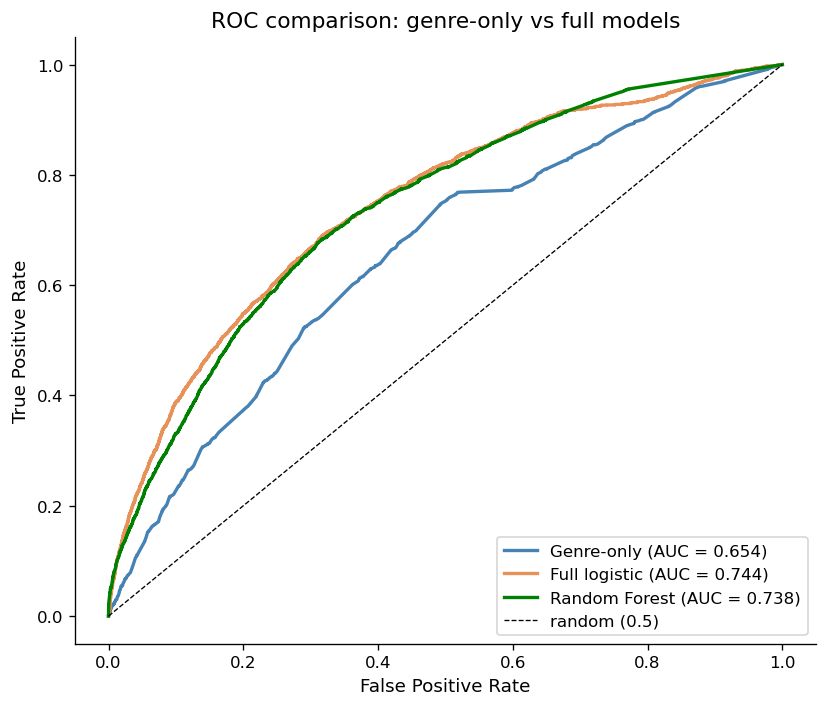

In [63]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, prob, color in [('Genre-only', y_prob_genre, 'steelblue'), ('Full logistic', y_prob_full, ACCENT), ('Random Forest', y_prob_rf, 'green')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='random (0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC comparison: genre-only vs full models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

So I put the three models side by side. The genre-only baseline gets an AUC of 0.654 while the full logistic gets 0.744 and the Random Forest 0.738. On the ROC plot I can see both full model curves (orange and green) sit above the genre-only curve (blue) across the whole range so the improvement isnt just a threshold thing the full models genuinely rank games better than genre alone everywhere.
Between the two full models they are basically tied on AUC (0.744 vs 0.738) but at the default threshold the logistic is much better at actually catching successes. The forest plays it safe and predicts not-success for most games so even though its AUC is fine it misses most of the real successes. So I stick with the logistic as my main model.

So for the client's main question, yes, combining multiple pre-launch features gives real decision value beyond a genre-only strategy. The genre-only model is better than random (0.654) but the full model adds about +0.09 AUC on top of it. That said it is still a moderate 0.744 so I read it as a useful screening tool for ranking concepts, not a precise yes or no predictor.

In [66]:
# Client question which pre-launch attributes matter most??
coef = pd.Series(clf_full.coef_[0], index=X.columns).sort_values()
print(coef.round(3).to_string())

Casual                  -0.296
is_self_published       -0.290
Early Access            -0.111
release_month           -0.031
Sports                  -0.029
Indie                   -0.001
Racing                   0.033
Adventure                0.041
plat_linux               0.050
Simulation               0.060
price_log                0.067
Massively Multiplayer    0.082
Free To Play             0.150
Strategy                 0.160
RPG                      0.162
Action                   0.183
age_restricted           0.199
plat_mac                 0.280
n_languages_log          0.470


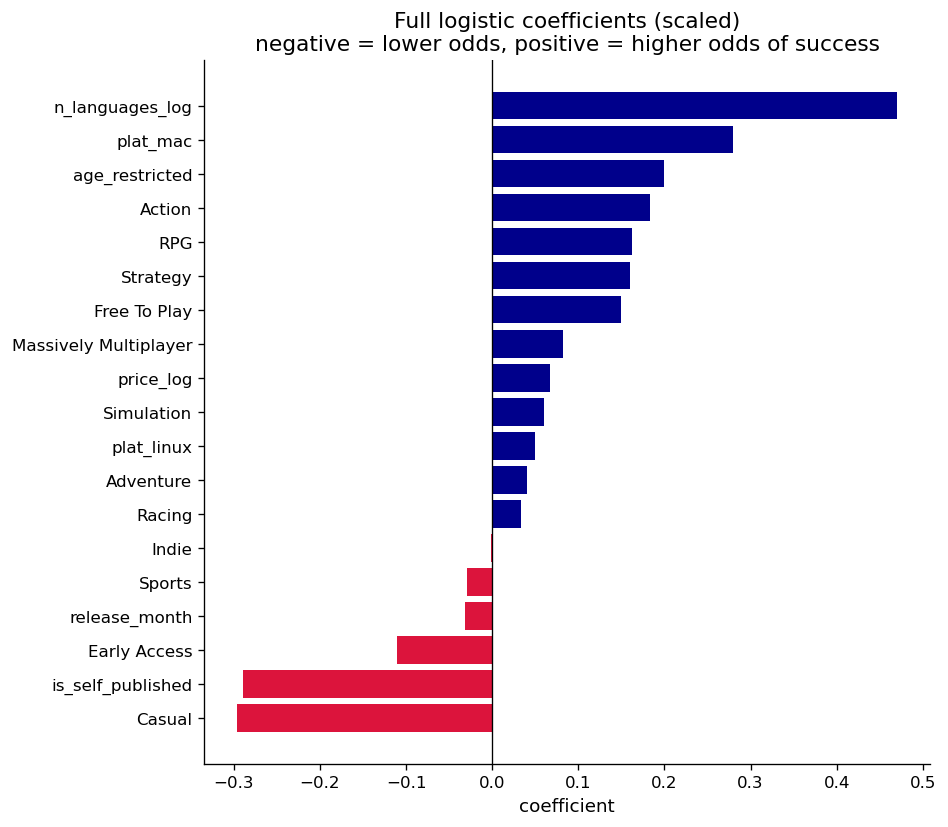

In [67]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['crimson' if c < 0 else 'darkblue' for c in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Full logistic coefficients (scaled)\nnegative = lower odds, positive = higher odds of success')
ax.set_xlabel('coefficient')
plt.tight_layout()
plt.show()

The biggest positive one by far is n_languages_log at +0.47 so the number of languages a game supports is the strongest single pull toward success in my model even stronger than any genre. After that comes plat_mac (+0.28) and age_restricted (+0.20) then the higher-success genres Action, RPG, Strategy, Free To Play. price_log is positive but small tho (+0.07).
On the negative side the two biggest are Casual (-0.30) and is_self_published (-0.29) then Early Access (-0.11). Indie sits basically at zero so once I account for everything else it barely moves success on its own. release_month is also tiny so when in the year a game comes out doesnt matter much here.
Worth to note that they are associations not causes. For examople like n_languages_log being on top prolly reflects that games with lots of languages are ones the studio invested more in like localization and a bigger budget. So these are pre-launch traits that tend to go with success not switches that guarantee it.

Based on all of this here is what I would tell the Director.

First, dont pick projects on genre alone. Genre does matter certain genres like MMO, RPG, Strategy, Action and Free To Play are tied to higher success and Casual and Early Access to lower but a genre-only screen is weak (AUC 0.65). Combining genre with the other pre-launch traits ranks concepts noticeably better (AUC 0.74) so I would screen on the whole picture not just genre.

Second, watch the pre-launch traits that tend to go with success. In my model the strongest ones are broad language support and being available on more platforms like Mac, plus sitting in one of the higher-success genres. Self-published, Casual and Early Access projects tend to sit lower. These are all visible before launch, so they can feed an early go/no-go screen.

Third, use the model as a ranking tool, not a guarantee. The full model reaches a moderate AUC of 0.74 and its precision on success is low (about 0.22) so it flags a lot of games that wont end up succeeding. I would use it to rank and shortlist concepts for a closer look not to auto-approve or auto-reject.

Last, there are limitations. The success line is 50000+ owners from a current snapshot, so older games have an unfair edge (I dropped release year but the sample still mixes ages). And everything here is association not causation so a trait going with success doesnt mean forcing it will create success.